# BİL 401  NYC Taxi Bench
## Apache Spark ve Apache DataFusion Karşılaştırmalı Analizi ve Kural Tabanlı Sorgu Yönlendirici

**Nisa Naz Keleşoğlu · İclal Zeynep Kaya · Zeynep Saçaklı**

Bu notebookda, "NYC For-Hire Vehicle Cost & Time Estimation" uygulamasının pipelineı vardır: veri toplama, ETL boru hattı, iki sorgu motorunun kontrollü
karşılaştırması ve ölçüm sonuçlarından türetilmiş bir sorgu yönlendirici (dispatcher).

### İçerik

| Bölüm | İçerik |
|---|---|
| 0 | Ortam kurulumu ve Spark oturumu |
| 1 | Ham veri toplama |
| 2 | ETL boru hattı ve veri doğrulama |
| 3 | Ölçüm altyapısı (süre + bellek metodolojisi) |
| 4 | Motor kurulumu ve semantik denklik testi |
| 5 | Deneyler: hacim, karmaşıklık, soğuk/sıcak cache |
| 6 | Ampirik maliyet modeli kalibrasyonu |
| 7 | Sorgu yönlendirici (dispatcher) - üç aşamalı gelişim |
| 8 | Çapraz doğrulama (cross-validation) |
| 9 | Uygulama demosu ve sonuçların dışa aktarımı |

### Çalıştırma notu

Notebook uçtan uca (**Restart Kernel - > Run All**) çalışacak biçimde tasarlanmıştır.
Hücreler baştan sona sıralı bağımlıdır; ara bir hücreyi tek başına çalıştırmadan önce
üstündeki hücrelerin çalıştırılmış olması gerekir.

Dependencyler `requirements.txt` ile yönetilir:

```
pip install -r requirements.txt
```

---
# Bölüm 0 - Ortam Kurulumu

### 0.1 Kütüphaneler

Notebookun ihtiyaç duyduğu tüm paketler içe aktarılır.

In [4]:
import os
import sys
import gc
import time
import uuid
import shutil
import threading
import statistics
import urllib.request

import numpy as np
import pandas as pd
import psutil


import pyarrow.dataset as ds
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


In [5]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.9 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 5.4 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.5 MB 5.7 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.5 MB 5.8 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 5.8 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 5.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 5.9 MB/s eta 0:00:01
   -------------------------------------- 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 0.2 Spark Oturumu

Spark, tek makine üzerinde local[*] modunda yapılandırılmıştır. Sürücü ve executor bellek sınırları 4 GB olarak verilmiştir; bu sınır, ETL boru hattının bellek
profilini öngörülebilir kılmak için yapılan bir kısıttır.

JAVA_HOME ataması işletim sistemine göre dinamik yapılır. Java 17+ sürümlerinde modül erişim kısıtları nedeniyle Spark'ın ihtiyaç duyduğu `--add-opens` izinleri JVM seçenekleri olarak verilir.

In [ ]:
# PySpark'ın, defterin çalıştığı sanal ortamın Python'unu kullanmasını garanti eder
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Yerel ağ/IP kopmalarını engeller
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "127.0.0.1"

# İşletim sistemine göre JAVA_HOME 
if sys.platform.startswith("win"):
    os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot"
elif sys.platform == "darwin":
    os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-21.jdk/Contents/Home"
else:
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-21-openjdk"

# Java 17+ modül erişim izinleri
java_options = (
    "--add-opens=java.base/java.lang=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
    "--add-opens=java.base/java.io=ALL-UNNAMED "
    "--add-opens=java.base/java.net=ALL-UNNAMED "
    "--add-opens=java.base/java.nio=ALL-UNNAMED "
    "--add-opens=java.base/java.util=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED "
    "--add-opens=java.base/sun.security.action=ALL-UNNAMED "
    "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED "
    "-Djdk.reflect.useDirectMethodHandle=false"
)

spark = (SparkSession.builder
    .appName("NYC_Taxi_Bench")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.extraJavaOptions", java_options)
    .config("spark.executor.extraJavaOptions", java_options)
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")

print("Spark oturumu başlatıldı.")
print(f"Spark sürümü : {spark.version}")
print(f"Python sürümü: {sys.version.split()[0]}")
print(f"Paralellik   : {spark.sparkContext.defaultParallelism} çekirdek")

Spark oturumu başlatıldı.
Spark sürümü : 3.5.1
Python sürümü: 3.14.6
Paralellik   : 16 çekirdek


### 0.3 Dizin Yolları

In [7]:
RAW_DIR         = "data/raw"
CLEAN_DIR       = "data/clean/yellow_tripdata_2023"
CLEAN_DATA_PATH = CLEAN_DIR + "/"                      # DataFusion / PyArrow için
LOOKUP_PATH     = RAW_DIR + "/taxi_zone_lookup.csv"
RESULTS_DIR     = "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Ham veri     : {RAW_DIR}")
print(f"Temiz veri   : {CLEAN_DIR}")
print(f"Referans tab.: {LOOKUP_PATH}")
print(f"Sonuçlar     : {RESULTS_DIR}")

Ham veri     : data/raw
Temiz veri   : data/clean/yellow_tripdata_2023
Referans tab.: data/raw/taxi_zone_lookup.csv
Sonuçlar     : results


---
# Bölüm 1 - Ham Veri Toplama

Veri kaynağı, New York City Taxi & Limousine Commission (TLC) resmi portalıdır. 2023 yılının 12 ayına ait Yellow Taxi kayıtları ile bölge kodlarını mahalle adlarına eşleyen taxi_zone_lookup.csv referans tablosu indirilir.

İndirme adımı idempotenttir: diskte hazırda bulunan dosyalar tekrar indirilmez.

In [8]:
os.makedirs(RAW_DIR, exist_ok=True)
TLC_BASE = "https://d37ci6vzurychx.cloudfront.net"

indirilen = 0
for m in range(1, 13):
    fname = f"yellow_tripdata_2023-{m:02d}.parquet"
    dest = f"{RAW_DIR}/{fname}"
    if not os.path.exists(dest):
        print(f"İndiriliyor: {fname}")
        urllib.request.urlretrieve(f"{TLC_BASE}/trip-data/{fname}", dest)
        indirilen += 1

if not os.path.exists(LOOKUP_PATH):
    print("İndiriliyor: taxi_zone_lookup.csv")
    urllib.request.urlretrieve(f"{TLC_BASE}/misc/taxi_zone_lookup.csv", LOOKUP_PATH)
    indirilen += 1

parquet_files = sorted(f for f in os.listdir(RAW_DIR) if f.endswith(".parquet"))
raw_bytes = sum(os.path.getsize(f"{RAW_DIR}/{f}") for f in parquet_files)

print(f"\nYeni indirilen dosya : {indirilen}")
print(f"Ham parquet dosyası  : {len(parquet_files)}")
print(f"Ham veri boyutu      : {raw_bytes / (1024**2):.2f} MB")
print(f"Referans tablosu     : {'mevcut' if os.path.exists(LOOKUP_PATH) else 'EKSİK'}")


Yeni indirilen dosya : 0
Ham parquet dosyası  : 12
Ham veri boyutu      : 606.29 MB
Referans tablosu     : mevcut


### 1.1 Ham Veri Şeması

Ham kayıtların şeması ve satır sayısı incelenerek, projection adımında hangi kolonların elenebileceği belirlenir.

In [9]:
ornek = spark.read.parquet(f"{RAW_DIR}/yellow_tripdata_2023-01.parquet")
print(f"Ham kolon sayısı: {len(ornek.columns)}")
print("Kolonlar:", ", ".join(ornek.columns))

raw_rows = spark.read.parquet(f"{RAW_DIR}/yellow_tripdata_2023-*.parquet").count()
print(f"\nToplam ham satır sayısı: {raw_rows:,}")

Ham kolon sayısı: 19
Kolonlar: VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, airport_fee

Toplam ham satır sayısı: 38,310,226


---
# Bölüm 2 - ETL Boru Hattı

Ham veri, gerçek dünya operasyonlarından toplandığı için sistemsel hatalar (bozuk zaman damgaları, negatif ücretler, geçersiz bölge kodları) içerir.
Aşağıdaki filtreler bu sistemsel hataları ayıklar:

| Adım | Kural | Gerekçe |
|---|---|---|
| Projeksiyon | 19 kolondan 6'sı seçilir | Disk I/O ve bellek ayak izini azaltmak |
| Null eleme | Seçili kolonlarda null olan satırlar | Ham veride PULocationID/DOLocationID null kayıtları mevcut |
| Tekilleştirme | Birebir aynı satırlar | Kaynak sistemden gelen tekrarlı kayıtlar |
| Zaman mantığı | dropoff > pickup, pickup_year == 2023 | Senkronizasyon hataları ve dönem dışı kayıtlar |
| Süre | 30 sn < süre < 5 saat | İptal edilen yolculuklar ve açık unutulan taksimetreler |
| Ücret | 0 < total_amount < 500 | İptaller ve "fat-finger" giriş hataları |
| Mesafe | 0 < trip_distance < 100 mil | Cihaz arızası kaynaklı uçuk değerler |
| Bölge | 1 ≤ LocationID ≤ 263 | 264/265 kodları "Bilinmeyen Bölge" anlamına gelir |

### Bellek yönetimi kararı

İlk denemelerde 12 aylık veri kümesinin tek seferde okunması OutOfMemoryError ile sonuçlanmıştır. Boru hattı bu nedenle **ay bazında iteratif** olarak yeniden tasarlanmıştır: her ay ayrı okunur, temizlenir ve partitionBy ile diske yazılır.
Bu yaklaşım bellek tüketimini sabit tutar ve olası bir hatada süreci baştan başlatma zorunluluğunu ortadan kaldırır.



Boru hattı mode("append") ile yazdığı için idempotent değildir: döngünün birden çok kez çalıştırılması veriyi çoğaltır. Bu davranış geliştirme sırasında somut olarak gözlemlenmiş (temiz veri 720 MB yerine 1440 MB, satır sayısı 36.5M yerine 73M), ve çözüm olarak boru hattının başına açık bir temizleme adımı eklenmiştir.

In [ ]:
#  idempotentlik 
# append modunda yazdığımız için, çıktı dizini varsa önce tamamen silinir.
# Bu adım olmadan döngüher çalıştığında veriyi çoğaltır .
if os.path.exists(CLEAN_DIR):
    shutil.rmtree(CLEAN_DIR)
    print("Mevcut temiz veri dizini silindi (idempotentlik garantisi).\n")

SELECTED_COLUMNS = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID",
    "trip_distance", "total_amount",
]

etl_timings = []
etl_start = time.perf_counter()

for month in range(1, 13):
    file_path = f"{RAW_DIR}/yellow_tripdata_2023-{month:02d}.parquet"
    if not os.path.exists(file_path):
        print(f"Ay {month:02d}: dosya bulunamadı, atlanıyor.")
        continue

    t0 = time.perf_counter()
    df_month = spark.read.parquet(file_path)

    # 1) Projection pruning — 19 kolondan 6'sı
    df_cleaned = df_month.select(*SELECTED_COLUMNS)

    # 2) Null ve tekrarlı kayıtların elenmesi
    df_cleaned = df_cleaned.dropna(subset=SELECTED_COLUMNS).dropDuplicates()

    # 3) Türetilmiş kolonlar
    df_cleaned = (df_cleaned
        .withColumn("pickup_year",  F.year(F.col("tpep_pickup_datetime")))
        .withColumn("pickup_month", F.month(F.col("tpep_pickup_datetime")))
        .withColumn("trip_duration_seconds",
                    F.unix_timestamp("tpep_dropoff_datetime") -
                    F.unix_timestamp("tpep_pickup_datetime")))

    # 4) Temizlik filtreleri
    df_cleaned = (df_cleaned.filter(
            (F.col("pickup_year") == 2023) &
            (F.col("pickup_month") == month) &
            (F.col("total_amount") > 0.0)   & (F.col("total_amount") < 500.0) &
            (F.col("trip_distance") > 0.0)  & (F.col("trip_distance") < 100.0) &
            (F.col("PULocationID").between(1, 263)) &
            (F.col("DOLocationID").between(1, 263)) &
            (F.col("trip_duration_seconds") > 30) &
            (F.col("trip_duration_seconds") < 18000))
        .withColumn("PULocationID", F.col("PULocationID").cast("long"))
        .withColumn("DOLocationID", F.col("DOLocationID").cast("long")))

    # 5) Bölümlenmiş yazma
    (df_cleaned.write
        .mode("append")
        .partitionBy("pickup_year", "pickup_month")
        .parquet(CLEAN_DIR))

    elapsed = time.perf_counter() - t0
    etl_timings.append({"Ay": month, "Süre_sn": round(elapsed, 2)})
    print(f"Ay {month:02d} tamamlandı — {elapsed:6.2f} sn")

etl_total = time.perf_counter() - etl_start
df_etl = pd.DataFrame(etl_timings)
if len(df_etl):
    print(f"\nETL boru hattı tamamlandı: {etl_total:.2f} sn "
          f"(ay başına ortalama {df_etl['Süre_sn'].mean():.2f} sn)")
    display(df_etl)
else:
    print("\nUYARI: Hiçbir ay işlenmedi — ham veri dizinini kontrol edin.")

Mevcut temiz veri dizini silindi (idempotentlik garantisi).

Ay 01 tamamlandı —   7.46 sn
Ay 02 tamamlandı —   4.60 sn
Ay 03 tamamlandı —   4.50 sn
Ay 04 tamamlandı —   4.43 sn
Ay 05 tamamlandı —   4.38 sn
Ay 06 tamamlandı —   4.04 sn
Ay 07 tamamlandı —   3.67 sn
Ay 08 tamamlandı —   2.22 sn
Ay 09 tamamlandı —   2.17 sn
Ay 10 tamamlandı —   2.67 sn
Ay 11 tamamlandı —   2.78 sn
Ay 12 tamamlandı —   2.45 sn

ETL boru hattı tamamlandı: 45.37 sn (ay başına ortalama 3.78 sn)


,Ay,Süre_sn
0,1,7.46
1,2,4.60
2,3,4.50
3,4,4.43
4,5,4.38
5,6,4.04
6,7,3.67
7,8,2.22
8,9,2.17
9,10,2.67


### 2.1 Veri Doğrulama

Boru hattının doğru çalıştığı üç kontrolle doğrulanır: dizin boyutu, part-file sayısı ve satır sayısı. Satır sayısı beklenen aralığın dışındaysa veri çoğaltılmış demektir ve sonraki hiçbir ölçüm geçerli olmaz.

In [ ]:
def get_dir_info(path, only_ext=None):
    # Bir dizindeki dosya sayısını ve toplam boyutu (MB) döner.
    file_count, total_bytes = 0, 0
    for root, _, files in os.walk(path):
        for f in files:
            if only_ext and not f.endswith(only_ext):
                continue
            file_count += 1
            total_bytes += os.path.getsize(os.path.join(root, f))
    return file_count, total_bytes / (1024 * 1024)

raw_count, raw_mb     = get_dir_info(RAW_DIR, only_ext=".parquet")
clean_count, clean_mb = get_dir_info(CLEAN_DIR)

print(f"Ham veri    : {raw_count} parquet dosyası | {raw_mb:.2f} MB")
print(f"Temiz veri  : {clean_count} part-file      | {clean_mb:.2f} MB")

if clean_count == 0:
    print("\nTemiz veri bulunamadı — önce ETL hücresini çalıştırın.")
else:
    clean_rows = spark.read.parquet(CLEAN_DIR).count()
    kept = 100 * clean_rows / raw_rows
    print(f"\nHam satır   : {raw_rows:,}")
    print(f"Temiz satır : {clean_rows:,}")
    print(f"Korunan     : %{kept:.2f}   |   Elenen: %{100 - kept:.2f} "
          f"({raw_rows - clean_rows:,} satır)")
    print(f"Boyut değişimi: {raw_mb:.1f} MB -> {clean_mb:.1f} MB "
          f"(%{100 * (clean_mb - raw_mb) / raw_mb:+.1f})")
    print("\nDURUM:", "OK" if 36_000_000 < clean_rows < 37_500_000
          else "!!! BEKLENMEYEN SATIR SAYISI - VERİ ÇOĞALTILMIŞ OLABİLİR !!!")

Ham veri    : 12 parquet dosyası | 606.29 MB
Temiz veri  : 410 part-file      | 719.97 MB

Ham satır   : 38,310,226
Temiz satır : 36,542,807
Korunan     : %95.39   |   Elenen: %4.61 (1,767,419 satır)
Boyut değişimi: 606.3 MB -> 720.0 MB (%+18.7)

DURUM: OK


### 2.2 Filtre Kırılımı

Bir satır birden fazla kuralı ihlal edebileceğinden bu sayılar ayrı hesaplanmamalıdır; toplamları elenen satır sayısından büyük olabilir. Amaç, hangi anomali türünün veri kümesinde baskın olduğunu görmektir.

In [12]:
ihlal_toplam = None

for month in range(1, 13):
    file_path = f"{RAW_DIR}/yellow_tripdata_2023-{month:02d}.parquet"
    if not os.path.exists(file_path):
        continue

    d = (spark.read.parquet(file_path).select(*SELECTED_COLUMNS)
         .withColumn("pickup_year", F.year("tpep_pickup_datetime"))
         .withColumn("dur", F.unix_timestamp("tpep_dropoff_datetime") -
                            F.unix_timestamp("tpep_pickup_datetime")))

    def say(cond):
        return F.sum(F.when(cond, 1).otherwise(0))

    row = d.agg(
        F.count("*").alias("ham_satir"),
        say(F.col("PULocationID").isNull() | F.col("DOLocationID").isNull() |
            F.col("total_amount").isNull() | F.col("trip_distance").isNull()).alias("null_kayit"),
        say(F.col("pickup_year") != 2023).alias("donem_disi"),
        say((F.col("total_amount") <= 0) | (F.col("total_amount") >= 500)).alias("ucret_ihlali"),
        say((F.col("trip_distance") <= 0) | (F.col("trip_distance") >= 100)).alias("mesafe_ihlali"),
        say((F.col("dur") <= 30) | (F.col("dur") >= 18000)).alias("sure_ihlali"),
        say((~F.col("PULocationID").between(1, 263)) |
            (~F.col("DOLocationID").between(1, 263))).alias("bolge_ihlali"),
    ).toPandas()

    ihlal_toplam = row if ihlal_toplam is None else ihlal_toplam.add(row, fill_value=0)
    print(f"Ay {month:02d} tarandı")

ihlal = ihlal_toplam.iloc[0].astype("int64")
ham = int(ihlal["ham_satir"])

df_ihlal = pd.DataFrame({
    "Kural": ["Null kayıt", "Dönem dışı (2023 değil)", "Ücret ihlali",
              "Mesafe ihlali", "Süre ihlali", "Geçersiz bölge kodu"],
    "Eşleşen_Satır": [int(ihlal["null_kayit"]), int(ihlal["donem_disi"]),
                      int(ihlal["ucret_ihlali"]), int(ihlal["mesafe_ihlali"]),
                      int(ihlal["sure_ihlali"]), int(ihlal["bolge_ihlali"])],
})
df_ihlal["Ham_Veriye_Oran_%"] = (100 * df_ihlal["Eşleşen_Satır"] / ham).round(4)

print(f"\nHam satır: {ham:,}")
display(df_ihlal.sort_values("Eşleşen_Satır", ascending=False).reset_index(drop=True))
df_ihlal.to_csv(os.path.join(RESULTS_DIR, "filtre_kirilimi.csv"), index=False)
print("Not: Kurallar ayrık değildir; bir satır birden fazla kuralı ihlal edebilir.")

Ay 01 tarandı
Ay 02 tarandı
Ay 03 tarandı
Ay 04 tarandı
Ay 05 tarandı
Ay 06 tarandı
Ay 07 tarandı
Ay 08 tarandı
Ay 09 tarandı
Ay 10 tarandı
Ay 11 tarandı
Ay 12 tarandı

Ham satır: 38,310,226


,Kural,Eşleşen_Satır,Ham_Veriye_Oran_%
0,Mesafe ihlali,774761,2.0223
1,Geçersiz bölge kodu,633591,1.6538
2,Ücret ihlali,383544,1.0012
3,Süre ihlali,381002,0.9945
4,Dönem dışı (2023 değil),104,0.0003
5,Null kayıt,0,0.0000


Not: Kurallar ayrık değildir; bir satır birden fazla kuralı ihlal edebilir.


---
# Bölüm 3 - Ölçüm Altyapısı

Karşılaştırmanın güvenilirliği, ölçüm yönteminin güvenirliğine bağlıdır. Bu bölümde tanımlanan altyapı üç metodolojik sorunu çözer:

**1.** Spark yerel modda JVM'i Python sürücüsünün alt süreci olarak başlatır. Yalnızca ana sürecin RSS değeri ölçüldüğünde Spark'ın bellek tüketimi sıfıra yakın görünür bu da ölçümü hatalı yapar. Burada psutil.Process.children(recursive=True) ile alt süreçler de toplanır.

**2.** Sorgu öncesi/sonrası fark, sorgu sırasında ayrılıp serbest bırakılan belleği kaçırır. 50 ms aralıkla örnekleyen bir izleme iş parçacığı ile peak tüketim ölçülür.

**3.** Her ölçüm bir soğuk koşu ve ardından N sıcak koşudan oluşur. Sıcak koşular için medyan ve standart sapma raporlanır; soğuk/sıcak farkı ise JVM ısınması ve işletim sistemi sayfa önbelleğinin etkisini ayrıştırır.

In [ ]:
def _total_rss_mb():
  
    p = psutil.Process(os.getpid())
    total = p.memory_info().rss
    for c in p.children(recursive=True):
        try:
            total += c.memory_info().rss
        except psutil.Error:
            pass
    return total / (1024 * 1024)


def measure(fn, interval=0.05):
 
    baseline = _total_rss_mb()
    peak = [baseline]
    stop = threading.Event()

    def sampler():
        while not stop.is_set():
            try:
                peak[0] = max(peak[0], _total_rss_mb())
            except psutil.Error:
                pass
            stop.wait(interval)

    th = threading.Thread(target=sampler, daemon=True)
    th.start()
    t0 = time.perf_counter()
    try:
        result = fn()
    finally:
        elapsed = time.perf_counter() - t0
        stop.set()
        th.join()
    return result, elapsed, peak[0] - baseline


def run_benchmark(engine_name, query_func, repeats=3, verbose=True):
 
    gc.collect()
    result, cold, peak_cold = measure(query_func)

    warm = []
    for _ in range(repeats):
        gc.collect()
        _, el, _ = measure(query_func)
        warm.append(el)

    warm_med = statistics.median(warm)
    row = {
        "Engine": engine_name,
        "Cold_sec": round(cold, 4),
        "Warm_median_sec": round(warm_med, 4),
        "Warm_stdev_sec": round(statistics.pstdev(warm), 4),
        "Cold_to_warm_speedup": round(cold / warm_med, 2) if warm_med > 0 else float("nan"),
        "Peak_RAM_MB": round(peak_cold, 1),
        "Result_Rows": len(result),
    }
    if verbose:
        print(f"  {engine_name:14s}: soğuk {row['Cold_sec']:.4f}s | "
              f"sıcak {row['Warm_median_sec']:.4f}s (±{row['Warm_stdev_sec']:.4f}) | "
              f"tepe RAM {row['Peak_RAM_MB']:.1f} MB")
    return row


ENGINE_ORDER = ["DataFusion", "Apache Spark"]
REPEATS = 3

print("Ölçüm altyapısı hazır.")
print(f"Ölçüm protokolü: 1 soğuk + {REPEATS} sıcak koşu, tepe bellek örneklemesi 50 ms")

Ölçüm altyapısı hazır.
Ölçüm protokolü: 1 soğuk + 3 sıcak koşu, tepe bellek örneklemesi 50 ms


---
# Bölüm 4 - Motor Kurulumu ve Semantik Denklik

Karşılaştırmanın adil olabilmesi için iki motorun aynı temiz veri üzerinde aynı relational sonucu ürettiği önce doğrulanmalıdır. Yoksa ölçülen süre farkı, farklı miktarda iş yapmaktan kaynaklanıyor olabilir.

### ANSI SQL uyumluluğunda gözlemlenen fark

Geliştirme sırasında somut bir taşınabilirlik sorunu tespit edilmiştir: ANSI SQL standardında tırnaksız tanımlayıcılar küçük harfe indirgenir. DataFusion bu kurala katı biçimde uyduğu için PULocationID gibi karışık büyük/küçük harfli kolon adlarını çift tırnak içinde bekler; Spark ise tırnaksız kabul eder.

Bu, "aynı SQL metni iki motorda da çalışır" varsayımının koşulsuz doğru olmadığını gösterir ve yönlendirici katmanının sözdizimsel bir dönüşüm katmanına ihtiyaç duyabileceğine işaret eder.

In [ ]:
from datafusion import SessionContext

ctx = SessionContext()

def df_register(path=CLEAN_DATA_PATH):
    # DataFusion'a benzersiz adla bölümlenmiş veri kümesi kaydeder.
    
    table_name = f"trips_{uuid.uuid4().hex}"
    ctx.register_dataset(table_name, ds.dataset(path, format="parquet", partitioning="hive"))
    return table_name

def df_register_lookup():
    name = f"zones_{uuid.uuid4().hex}"
    ctx.register_csv(name, LOOKUP_PATH)
    return name

print("DataFusion oturumu hazır.")

DataFusion oturumu hazır.


### 4.1 Semantik Denklik Testi

Ocak 2023 verisi üzerinde "en yoğun ilk 5 mahalle çifti için ortalama ücret, ortalama
süre ve yolculuk sayısı" sorgusu her iki motorda çalıştırılır ve sonuç tabloları
karşılaştırılır.

In [15]:
JAN_PATH = f"{CLEAN_DIR}/pickup_year=2023/pickup_month=1"

def denklik_datafusion():
    tn = df_register(JAN_PATH)
    return ctx.sql(f'''
        SELECT "PULocationID", "DOLocationID",
               ROUND(CAST(AVG(total_amount) AS DOUBLE), 2)              AS avg_fare_usd,
               ROUND(CAST(AVG(trip_duration_seconds)/60.0 AS DOUBLE), 2) AS avg_minutes,
               COUNT(*) AS trip_count
        FROM {tn}
        GROUP BY "PULocationID", "DOLocationID"
        ORDER BY trip_count DESC
        LIMIT 5
    ''').to_pandas()

def denklik_spark():
    return (spark.read.parquet(JAN_PATH)
        .groupBy("PULocationID", "DOLocationID")
        .agg(F.round(F.avg("total_amount"), 2).alias("avg_fare_usd"),
             F.round(F.avg("trip_duration_seconds") / 60.0, 2).alias("avg_minutes"),
             F.count("*").alias("trip_count"))
        .orderBy(F.col("trip_count").desc())
        .limit(5)
        .toPandas())

res_df = denklik_datafusion()
res_sp = denklik_spark()

print("DataFusion:"); display(res_df)
print("Apache Spark:"); display(res_sp)

ortusme = np.allclose(
    res_df[["avg_fare_usd", "avg_minutes", "trip_count"]].values.astype(float),
    res_sp[["avg_fare_usd", "avg_minutes", "trip_count"]].values.astype(float),
    atol=0.01)
print(f"\nSemantik denklik (ilk 5 satır birebir örtüşüyor mu?): {ortusme}")

DataFusion:


,PULocationID,DOLocationID,avg_fare_usd,avg_minutes,trip_count
0,237,236,15.43,6.98,22081
1,236,237,15.99,8.04,18823
2,236,236,13.21,4.95,14227
3,237,237,13.64,5.55,13851
4,237,161,16.22,8.75,9302


Apache Spark:


,PULocationID,DOLocationID,avg_fare_usd,avg_minutes,trip_count
0,237,236,15.43,6.98,22081
1,236,237,15.99,8.04,18823
2,236,236,13.21,4.95,14227
3,237,237,13.64,5.55,13851
4,237,161,16.22,8.75,9302



Semantik denklik (ilk 5 satır birebir örtüşüyor mu?): True


---
# Bölüm 5 - Deneyler

Karşılaştırma üç eksende yürütülür:

1. Veri hacmi - 1 / 3 / 6 / 12 aylık tarama (Bölüm 5.1)
2. Sorgu karmaşıklığı - basit filtre ve agregasyon vs. broadcast join + geniş groupBy (Bölüm 5.2)
3. Cache durumu - soğuk ilk koşu vs. sıcak tekrar koşuları (her iki deneyde ölçülür)

Her ölçüm 1 soğuk + 3 sıcak koşudan oluşur; sıcak koşular için medyan ve standart sapma raporlanır.

### 5.1 Veri Hacmine Göre Ölçekleme

Bu deney, iki motorun hacme karşı eğimini ortaya koyar. Sabit maliyet (kesişim) başlangıç yükünü, eğim ise birim veri başına işleme maliyetini temsil eder. Bu iki katsayı Bölüm 6'da yönlendiricinin maliyet modelini kalibre etmek için doğrudan kullanılır.

Aynı sorgu her hacimde çalıştırılır; hacim, pickup_month üzerinden partition pruning ile kontrol edilir.

In [16]:
MONTH_SETS = {
    "1 ay":  [1],
    "3 ay":  [1, 2, 3],
    "6 ay":  list(range(1, 7)),
    "12 ay": list(range(1, 13)),
}

def scan_gb(months):
    # Partition pruning sonrası gerçekten okunacak bayt miktarı (GB).
    total = 0
    for m in months:
        d = f"{CLEAN_DIR}/pickup_year=2023/pickup_month={m}"
        for root, _, files in os.walk(d):
            for f in files:
                total += os.path.getsize(os.path.join(root, f))
    return total / (1024 ** 3)

def spark_scan(months):
    return (spark.read.parquet(CLEAN_DATA_PATH)
        .filter(F.col("pickup_month").isin(months))
        .groupBy("PULocationID", "DOLocationID")
        .agg(F.avg("total_amount").alias("avg_cost"), F.count("*").alias("n"))
        .toPandas())

def datafusion_scan(months):
    tn = df_register()
    lst = ",".join(str(m) for m in months)
    return ctx.sql(f'''
        SELECT "PULocationID", "DOLocationID",
               AVG(total_amount) AS avg_cost, COUNT(*) AS n
        FROM {tn}
        WHERE "pickup_month" IN ({lst})
        GROUP BY "PULocationID", "DOLocationID"
    ''').to_pandas()

VOL_ENGINES = {"DataFusion": datafusion_scan, "Apache Spark": spark_scan}

vol_rows = []
for label, months in MONTH_SETS.items():
    gb = scan_gb(months)
    print(f"\n--- {label} | {gb:.3f} GB ---")
    for engine in ENGINE_ORDER:
        fn = VOL_ENGINES[engine]
        row = run_benchmark(engine, lambda: fn(months), repeats=REPEATS)
        row.update({"Hacim": label, "Scan_GB": round(gb, 4), "Ay_Sayisi": len(months)})
        vol_rows.append(row)

df_vol = pd.DataFrame(vol_rows)[
    ["Hacim", "Ay_Sayisi", "Scan_GB", "Engine", "Cold_sec", "Warm_median_sec",
     "Warm_stdev_sec", "Cold_to_warm_speedup", "Peak_RAM_MB", "Result_Rows"]]
display(df_vol)
df_vol.to_csv(os.path.join(RESULTS_DIR, "hacim_olcekleme.csv"), index=False)
print(f"\n'{RESULTS_DIR}/hacim_olcekleme.csv' yazıldı.")


--- 1 ay | 0.056 GB ---
  DataFusion    : soğuk 0.0674s | sıcak 0.0493s (±0.0099) | tepe RAM 23.4 MB
  Apache Spark  : soğuk 1.4997s | sıcak 1.2282s (±0.0452) | tepe RAM 553.7 MB

--- 3 ay | 0.173 GB ---
  DataFusion    : soğuk 0.9471s | sıcak 0.1401s (±0.0124) | tepe RAM 167.2 MB
  Apache Spark  : soğuk 1.4046s | sıcak 1.2761s (±0.0280) | tepe RAM 48.7 MB

--- 6 ay | 0.360 GB ---
  DataFusion    : soğuk 1.3557s | sıcak 0.2353s (±0.0079) | tepe RAM 252.7 MB
  Apache Spark  : soğuk 1.4124s | sıcak 1.2551s (±0.0182) | tepe RAM 660.8 MB

--- 12 ay | 0.703 GB ---
  DataFusion    : soğuk 1.3807s | sıcak 0.6728s (±0.0214) | tepe RAM 374.5 MB
  Apache Spark  : soğuk 1.5628s | sıcak 1.4691s (±0.0683) | tepe RAM 7.4 MB


,Hacim,Ay_Sayisi,Scan_GB,Engine,Cold_sec,Warm_median_sec,Warm_stdev_sec,Cold_to_warm_speedup,Peak_RAM_MB,Result_Rows
0,1 ay,1,0.0563,DataFusion,0.0674,0.0493,0.0099,1.37,23.4,21028
1,1 ay,1,0.0563,Apache Spark,1.4997,1.2282,0.0452,1.22,553.7,21028
2,3 ay,3,0.1727,DataFusion,0.9471,0.1401,0.0124,6.76,167.2,29712
3,3 ay,3,0.1727,Apache Spark,1.4046,1.2761,0.0280,1.10,48.7,29712
4,6 ay,6,0.3595,DataFusion,1.3557,0.2353,0.0079,5.76,252.7,36444
5,6 ay,6,0.3595,Apache Spark,1.4124,1.2551,0.0182,1.13,660.8,36444
6,12 ay,12,0.7031,DataFusion,1.3807,0.6728,0.0214,2.05,374.5,42793
7,12 ay,12,0.7031,Apache Spark,1.5628,1.4691,0.0683,1.06,7.4,42793



'results/hacim_olcekleme.csv' yazıldı.


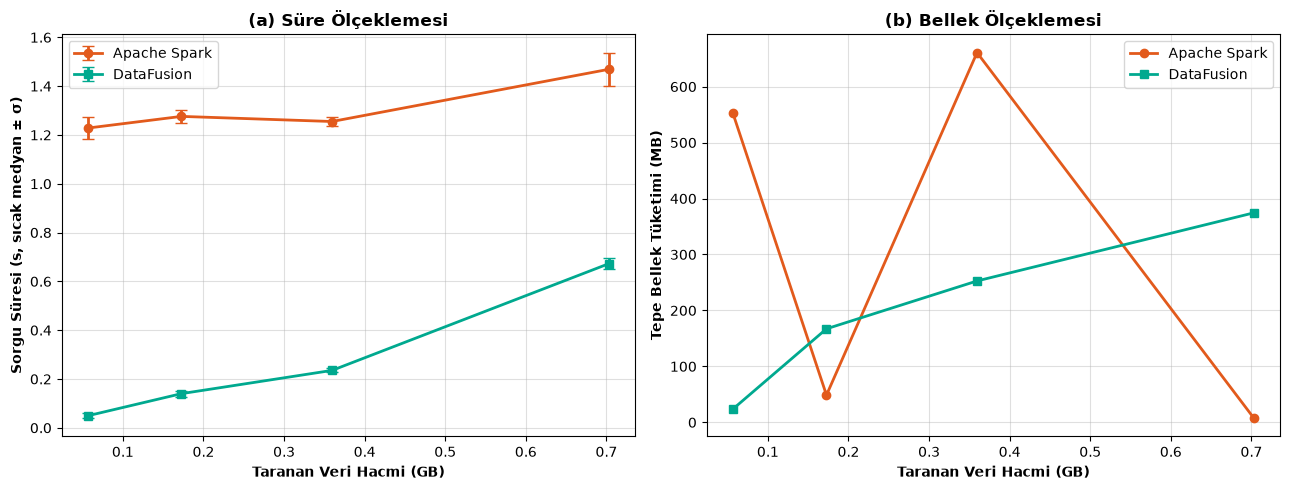

In [ ]:
import os
import matplotlib.pyplot as plt

STYLE = {"Apache Spark": ("#E25A1C", "o"), "DataFusion": ("#00A98F", "s")}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for engine, (color, mk) in STYLE.items():
    sub = df_vol[df_vol.Engine == engine].sort_values("Scan_GB")
    axes[0].errorbar(sub.Scan_GB, sub.Warm_median_sec, yerr=sub.Warm_stdev_sec,
                     marker=mk, capsize=4, linewidth=2, label=engine, color=color)
    axes[1].plot(sub.Scan_GB, sub.Peak_RAM_MB, marker=mk, linewidth=2,
                 label=engine, color=color)

axes[0].set_xlabel("Taranan Veri Hacmi (GB)", fontweight="bold")
axes[0].set_ylabel("Sorgu Süresi (s, sıcak medyan ± σ)", fontweight="bold")
axes[0].set_title("(a) Süre Ölçeklemesi", fontweight="bold")
axes[1].set_xlabel("Taranan Veri Hacmi (GB)", fontweight="bold")
axes[1].set_ylabel("Tepe Bellek Tüketimi (MB)", fontweight="bold")
axes[1].set_title("(b) Bellek Ölçeklemesi", fontweight="bold")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "sekil1_hacim_olcekleme.png"), dpi=200)
plt.show()

### 5.2 Sorgu Karmaşıklığı × Cache Durumu

İki sorgu karşılaştırılır:

- T1 - Basit filtre + agregasyon (1 ay): partition pruning devrede, taranan veri küçük.
- T2 - Broadcast join + geniş groupBy (12 ay): referans tablosu ile birleştirme ve mahalle bazında gruplama yani tam tarama.

T2'de Spark tarafında broadcast ipucu açıkça verilmiştir. Gruplama Borough ve Zone kolonlarının ikisi birden üzerinden yapılır: referans tablosunda aynı mahalle adı farklı ilçelerde tekrar edebildiği için yalnızca Zone ile gruplamak farklı bölgeleri sessizce birleştirir.

In [19]:
def t1_spark():
    return (spark.read.parquet(CLEAN_DATA_PATH)
        .filter((F.col("pickup_month") == 1) & (F.col("PULocationID") == 132))
        .agg(F.round(F.avg("total_amount"), 2).alias("avg_cost"),
             F.count("*").alias("n"))
        .toPandas())

def t1_datafusion():
    tn = df_register()
    return ctx.sql(f'''
        SELECT ROUND(CAST(AVG(total_amount) AS DOUBLE), 2) AS avg_cost, COUNT(*) AS n
        FROM {tn}
        WHERE "pickup_month" = 1 AND "PULocationID" = 132
    ''').to_pandas()

def t2_spark():
    sdf = spark.read.parquet(CLEAN_DATA_PATH)
    lookup = spark.read.csv(LOOKUP_PATH, header=True, inferSchema=True)
    return (sdf
        .join(F.broadcast(lookup), sdf.PULocationID == lookup.LocationID, "inner")
        .groupBy("Borough", "Zone")
        .agg(F.round(F.avg("total_amount"), 2).alias("avg_cost"),
             F.count("*").alias("trip_count"))
        .orderBy(F.col("trip_count").desc())
        .toPandas())

def t2_datafusion():
    tn = df_register()
    zn = df_register_lookup()
    return ctx.sql(f'''
        SELECT tz."Borough", tz."Zone",
               ROUND(CAST(AVG(ct.total_amount) AS DOUBLE), 2) AS avg_cost,
               COUNT(*) AS trip_count
        FROM {tn} ct
        JOIN {zn} tz ON ct."PULocationID" = tz."LocationID"
        GROUP BY tz."Borough", tz."Zone"
        ORDER BY trip_count DESC
    ''').to_pandas()

TESTS = {
    "T1: Basit Filtre (1 Ay)":    {"DataFusion": t1_datafusion, "Apache Spark": t1_spark},
    "T2: Broadcast JOIN (12 Ay)": {"DataFusion": t2_datafusion, "Apache Spark": t2_spark},
}

bench_rows = []
for test_name, engines in TESTS.items():
    print(f"\n=== {test_name} ===")
    for engine in ENGINE_ORDER:
        row = run_benchmark(engine, engines[engine], repeats=REPEATS)
        row["Test"] = test_name
        bench_rows.append(row)

df_benchmarks = pd.DataFrame(bench_rows)[
    ["Test", "Engine", "Cold_sec", "Warm_median_sec", "Warm_stdev_sec",
     "Cold_to_warm_speedup", "Peak_RAM_MB", "Result_Rows"]]
display(df_benchmarks)
df_benchmarks.to_csv(os.path.join(RESULTS_DIR, "karmasiklik_cache.csv"), index=False)
print(f"\n'{RESULTS_DIR}/karmasiklik_cache.csv' yazıldı.")


=== T1: Basit Filtre (1 Ay) ===
  DataFusion    : soğuk 0.0790s | sıcak 0.0411s (±0.0018) | tepe RAM 0.0 MB
  Apache Spark  : soğuk 0.4193s | sıcak 0.2337s (±0.0084) | tepe RAM 147.9 MB

=== T2: Broadcast JOIN (12 Ay) ===
  DataFusion    : soğuk 1.1265s | sıcak 0.9094s (±0.0696) | tepe RAM 1809.0 MB
  Apache Spark  : soğuk 3.7756s | sıcak 2.1215s (±0.1599) | tepe RAM 512.5 MB


,Test,Engine,Cold_sec,Warm_median_sec,Warm_stdev_sec,Cold_to_warm_speedup,Peak_RAM_MB,Result_Rows
0,T1: Basit Filtre (1 Ay),DataFusion,0.0790,0.0411,0.0018,1.92,0.0,1
1,T1: Basit Filtre (1 Ay),Apache Spark,0.4193,0.2337,0.0084,1.79,147.9,1
2,T2: Broadcast JOIN (12 Ay),DataFusion,1.1265,0.9094,0.0696,1.24,1809.0,260
3,T2: Broadcast JOIN (12 Ay),Apache Spark,3.7756,2.1215,0.1599,1.78,512.5,260



'results/karmasiklik_cache.csv' yazıldı.


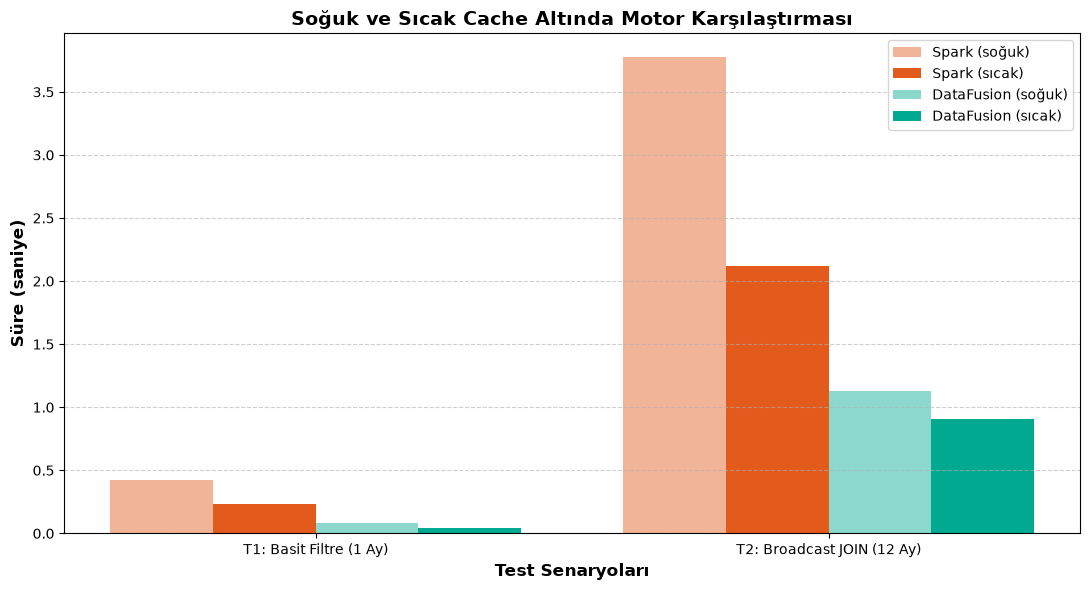

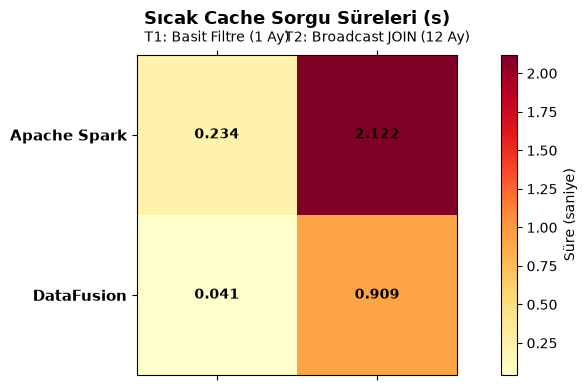

In [ ]:
# Şekil 2: Soğuk vs sıcak, test ve motor bazında
tests = list(df_benchmarks["Test"].unique())
x = np.arange(len(tests))
w = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
series = [
    ("Apache Spark", "Cold_sec",        0.45, "Spark (soğuk)"),
    ("Apache Spark", "Warm_median_sec", 1.00, "Spark (sıcak)"),
    ("DataFusion",   "Cold_sec",        0.45, "DataFusion (soğuk)"),
    ("DataFusion",   "Warm_median_sec", 1.00, "DataFusion (sıcak)"),
]
for k, (engine, col, alpha, label) in enumerate(series):
    sub = df_benchmarks[df_benchmarks.Engine == engine].set_index("Test").loc[tests]
    ax.bar(x + (k - 1.5) * w, sub[col].values, w,
           label=label, color=STYLE[engine][0], alpha=alpha)

ax.set_xticks(x); ax.set_xticklabels(tests, fontsize=10)
ax.set_xlabel("Test Senaryoları", fontweight="bold", fontsize=12)
ax.set_ylabel("Süre (saniye)", fontweight="bold", fontsize=12)
ax.set_title("Soğuk ve Sıcak Cache Altında Motor Karşılaştırması",
             fontweight="bold", fontsize=14)
ax.legend(fontsize=10); ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "sekil2_soguk_sicak.png"), dpi=200)
plt.show()

# Şekil 3: Sıcak cache ısı haritası
engines = ["Apache Spark", "DataFusion"]
matrix = np.array([[df_benchmarks[(df_benchmarks.Engine == e) &
                                  (df_benchmarks.Test == t)]["Warm_median_sec"].iloc[0]
                    for t in tests] for e in engines])

fig, ax = plt.subplots(figsize=(9, 4))
cax = ax.matshow(matrix, cmap="YlOrRd")
fig.colorbar(cax, label="Süre (saniye)")
ax.set_xticks(range(len(tests))); ax.set_xticklabels(tests, fontsize=10)
ax.set_yticks(range(len(engines))); ax.set_yticklabels(engines, fontsize=11, fontweight="bold")
for (i, j), val in np.ndenumerate(matrix):
    ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontweight="bold")
plt.title("Sıcak Cache Sorgu Süreleri (s)", pad=22, fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "sekil3_isi_haritasi.png"), dpi=200)
plt.show()

### 5.3 Ölçüm Sonuçlarının Özeti

Aşağıdaki hücre, makaleye girecek özet tabloyu ve otomatik yorumu üretir.
Sayılar doğrudan yukarıdaki ölçümlerden okunur; elle girilmiş hiçbir değer yoktur.

In [21]:
print("=" * 68)
print("ÖZET BULGULAR")
print("=" * 68)

for t in tests:
    sub = df_benchmarks[df_benchmarks.Test == t].set_index("Engine")
    sp, dfn = sub.loc["Apache Spark"], sub.loc["DataFusion"]
    hizli = "DataFusion" if dfn.Warm_median_sec < sp.Warm_median_sec else "Apache Spark"
    oran = max(sp.Warm_median_sec, dfn.Warm_median_sec) / min(sp.Warm_median_sec, dfn.Warm_median_sec)
    print(f"\n{t}")
    print(f"  Sıcak medyan : Spark {sp.Warm_median_sec:.4f}s | DataFusion {dfn.Warm_median_sec:.4f}s"
          f"  -> {hizli} {oran:.2f}x hızlı")
    print(f"  Soğuk koşu   : Spark {sp.Cold_sec:.4f}s | DataFusion {dfn.Cold_sec:.4f}s")
    print(f"  Isınma etkisi: Spark x{sp.Cold_to_warm_speedup:.2f} | DataFusion x{dfn.Cold_to_warm_speedup:.2f}")
    print(f"  Tepe bellek  : Spark {sp.Peak_RAM_MB:.1f} MB | DataFusion {dfn.Peak_RAM_MB:.1f} MB")

print("\n" + "=" * 68)
print("HACİM ÖLÇEKLEMESİ")
print("=" * 68)
pivot = df_vol.pivot_table(index=["Hacim", "Scan_GB"], columns="Engine",
                           values=["Warm_median_sec", "Peak_RAM_MB"]).round(3)
display(pivot.sort_index(level="Scan_GB"))

ÖZET BULGULAR

T1: Basit Filtre (1 Ay)
  Sıcak medyan : Spark 0.2337s | DataFusion 0.0411s  -> DataFusion 5.69x hızlı
  Soğuk koşu   : Spark 0.4193s | DataFusion 0.0790s
  Isınma etkisi: Spark x1.79 | DataFusion x1.92
  Tepe bellek  : Spark 147.9 MB | DataFusion 0.0 MB

T2: Broadcast JOIN (12 Ay)
  Sıcak medyan : Spark 2.1215s | DataFusion 0.9094s  -> DataFusion 2.33x hızlı
  Soğuk koşu   : Spark 3.7756s | DataFusion 1.1265s
  Isınma etkisi: Spark x1.78 | DataFusion x1.24
  Tepe bellek  : Spark 512.5 MB | DataFusion 1809.0 MB

HACİM ÖLÇEKLEMESİ


Peak_RAM_MB            Warm_median_sec           
Engine        Apache Spark DataFusion    Apache Spark DataFusion
Hacim Scan_GB                                                   
1 ay  0.0563         553.7       23.4           1.228      0.049
3 ay  0.1727          48.7      167.2           1.276      0.140
6 ay  0.3595         660.8      252.7           1.255      0.235
12 ay 0.7031           7.4      374.5           1.469      0.673

---
# Bölüm 6 - Ampirik Maliyet Modeli Kalibrasyonu

Yönlendiricinin motor seçimi, sabit ve gerekçesiz eşiklere değil, Bölüm 5.1'de ölçülen davranışa dayanmalıdır. Bu bölümde her motor için iki doğrusal model en küçük kareler ile uydurulur:

$$ t(v) = a_t + b_t \cdot v \qquad m(v) = a_m + b_m \cdot v $$

Burada $v$ taranan veri hacmi (GB), $t$ sorgu süresi (s), $m$ tepe bellek tüketimidir (MB). $a$ terimleri motorun sabit başlangıç maliyetini, $b$ terimleri birim veri başına maliyeti temsil eder.

Elde edilen katsayılar Bölüm 7'deki maliyet tabanlı optimizatöre doğrudan beslenir; böylece notebookda uydurma sabit kalmaz.

In [22]:
CALIBRATION = {}
for engine in ["Apache Spark", "DataFusion"]:
    sub = df_vol[df_vol.Engine == engine].sort_values("Scan_GB")
    v = sub["Scan_GB"].values.astype(float)
    bt, at = np.polyfit(v, sub["Warm_median_sec"].values.astype(float), 1)
    bm, am = np.polyfit(v, sub["Peak_RAM_MB"].values.astype(float), 1)
    CALIBRATION[engine] = {
        "time_fixed_s":   float(at), "time_per_gb_s":  float(bt),
        "mem_fixed_mb":   float(am), "mem_per_gb_mb":  float(bm),
    }

df_calib = pd.DataFrame(CALIBRATION).T.round(4)
df_calib.index.name = "Engine"
display(df_calib)
df_calib.to_csv(os.path.join(RESULTS_DIR, "kalibrasyon_katsayilari.csv"))

# Modellerin kesişim noktası: iki motorun tahmini süresinin eşitlendiği hacim
s, d = CALIBRATION["Apache Spark"], CALIBRATION["DataFusion"]
payda = s["time_per_gb_s"] - d["time_per_gb_s"]
if abs(payda) > 1e-9:
    kesisim = (d["time_fixed_s"] - s["time_fixed_s"]) / payda
    if kesisim > 0:
        print(f"\nModellerin kesişim noktası: {kesisim:.2f} GB")
        print("Bu hacmin üzerinde Spark'ın daha düşük eğimi avantaja dönüşür.")
    else:
        print(f"\nModeller ölçülen aralıkta kesişmiyor (kesişim {kesisim:.2f} GB < 0).")
        print("Ölçülen bantta DataFusion süre bakımından baskındır; Spark'ın")
        print("avantajı bellek profilinde aranmalıdır (bkz. Şekil 1b).")
else:
    print("\nEğimler neredeyse aynı; süre modelleri ayrışmıyor.")

print(f"\nÖlçüm aralığı: {df_vol.Scan_GB.min():.3f} – {df_vol.Scan_GB.max():.3f} GB")
print("Model bu aralık dışında ekstrapolasyon içerir; sınırlılık olarak raporlanmalıdır.")

,time_fixed_s,time_per_gb_s,mem_fixed_mb,mem_per_gb_mb
Engine,,,,
Apache Spark,1.192,0.3565,490.1121,-534.1039
DataFusion,-0.036,0.9612,42.3014,502.1636



Modellerin kesişim noktası: 2.03 GB
Bu hacmin üzerinde Spark'ın daha düşük eğimi avantaja dönüşür.

Ölçüm aralığı: 0.056 – 0.703 GB
Model bu aralık dışında ekstrapolasyon içerir; sınırlılık olarak raporlanmalıdır.


---
# Bölüm 7 - Sorgu Yönlendirici (Dispatcher)

Yönlendirici üç aşamada geliştirilmiştir. Her aşama bir öncekinin eksiğini kapatır:

| Sürüm | Karar girdisi | Eklenen yetenek |
|---|---|---|
| v1 - Temel | Sorgu tipi | Kural tabanlı statik yönlendirme |
| v2 - Kaynak farkındalıklı | Sorgu tipi + anlık RAM | Bellek baskısında güvenli motora çekilme |
| v3 - Nihai | Ampirik maliyet modeli + kaynak + zaman aşımı | Ölçüme dayalı seçim, fallback, önbellek, denetim izi |

### 7.1 v1 - Temel Yönlendirici

En basit haliyle yönlendirici, sorgu tipine bakarak statik bir kural uygular: nokta atışı tahmin sorguları DataFusion'a, geniş kapsamlı join ve agregasyon sorguları Spark'a gider. Ayrıca taranacak veri hacmini partition pruning'i hesaba katarak ölçer.

In [23]:
class QueryDispatcher:
    # v1 — Sorgu tipine dayalı statik kural tabanlı yönlendirici.

    def __init__(self, spark_session, datafusion_context):
        self.spark = spark_session
        self.ctx = datafusion_context

    def estimate_scan_gb(self, months=None):
        aylar = months if months else list(range(1, 13))
        return scan_gb(aylar)

    def route_and_execute(self, query_type, pickup_loc=132, dropoff_loc=230, month=1):
        t0 = time.perf_counter()
        gb = self.estimate_scan_gb([month] if query_type == "point_estimation" else None)
        print(f"[v1] Taranacak veri: {gb:.3f} GB")

        if query_type == "complex_join":
            print("[v1] Karar: karmaşık JOIN + agregasyon -> Apache Spark")
            engine, res = self._spark_join()
        else:
            print(f"[v1] Karar: nokta atışı tahmin (Ay {month}) -> DataFusion")
            engine, res = self._datafusion_estimation(pickup_loc, dropoff_loc, month)

        return engine, time.perf_counter() - t0, res

    def _spark_join(self):
        sdf = self.spark.read.parquet(CLEAN_DATA_PATH)
        lookup = self.spark.read.csv(LOOKUP_PATH, header=True, inferSchema=True)
        res = (sdf
            .join(F.broadcast(lookup), sdf.PULocationID == lookup.LocationID, "inner")
            .groupBy("Borough", "Zone")
            .agg(F.round(F.avg("total_amount"), 2).alias("avg_cost"),
                 F.round(F.avg("trip_duration_seconds") / 60.0, 2).alias("avg_minutes"),
                 F.count("*").alias("trip_count"))
            .orderBy(F.col("trip_count").desc())
            .limit(5)
            .toPandas())
        return "Apache Spark", res

    def _datafusion_estimation(self, p_loc, d_loc, month):
        tn = df_register()
        res = self.ctx.sql(f'''
            SELECT ROUND(CAST(AVG(total_amount) AS DOUBLE), 2)               AS avg_cost,
                   ROUND(CAST(AVG(trip_duration_seconds)/60.0 AS DOUBLE), 2) AS avg_minutes,
                   COUNT(*) AS historical_trip_count
            FROM {tn}
            WHERE "pickup_month" = {month}
              AND "PULocationID" = {p_loc} AND "DOLocationID" = {d_loc}
        ''').to_pandas()
        return "DataFusion", res


dispatcher_v1 = QueryDispatcher(spark, ctx)

print("--- Senaryo 1: Karmaşık JOIN ---")
eng, dur, res = dispatcher_v1.route_and_execute("complex_join")
print(f"Motor: {eng} | {dur:.3f} sn"); display(res)

print("\n--- Senaryo 2: Nokta atışı tahmin (JFK -> Times Square, Ocak) ---")
eng, dur, res = dispatcher_v1.route_and_execute("point_estimation", 132, 230, month=1)
print(f"Motor: {eng} | {dur:.3f} sn"); display(res)

--- Senaryo 1: Karmaşık JOIN ---
[v1] Taranacak veri: 0.703 GB
[v1] Karar: karmaşık JOIN + agregasyon -> Apache Spark
Motor: Apache Spark | 2.248 sn


,Borough,Zone,avg_cost,avg_minutes,trip_count
0,Queens,JFK Airport,79.69,42.44,1823441
1,Manhattan,Upper East Side South,20.67,11.98,1755551
2,Manhattan,Midtown Center,25.20,15.32,1721164
3,Manhattan,Upper East Side North,21.28,12.21,1562643
4,Manhattan,Midtown East,24.40,14.44,1322582



--- Senaryo 2: Nokta atışı tahmin (JFK -> Times Square, Ocak) ---
[v1] Taranacak veri: 0.056 GB
[v1] Karar: nokta atışı tahmin (Ay 1) -> DataFusion
Motor: DataFusion | 0.088 sn


,avg_cost,avg_minutes,historical_trip_count
0,92.35,49.66,5836


### 7.2 v2 - Kaynak Farkındalıklı Yönlendirici

Sistemin boş belleği kritik seviyeye indiğinde, sorgu ne kadar hafif görünürse görünsün, iş bellek profili öngörülebilir olan motora yönlendirilir.

In [24]:
class ResourceAwareQueryDispatcher(QueryDispatcher):
    # v2 — Anlık sistem kaynaklarını da karar girdisi olarak kullanır.

    RAM_CRITICAL_PERCENT = 85.0

    def system_metrics(self):
        vm = psutil.virtual_memory()
        return {"ram_percent": vm.percent,
                "available_gb": vm.available / (1024 ** 3),
                "cpu_percent": psutil.cpu_percent(interval=None)}

    def route_and_execute(self, query_type, pickup_loc=132, dropoff_loc=230, month=1):
        t0 = time.perf_counter()
        m = self.system_metrics()
        print(f"[v2] RAM %{m['ram_percent']:.1f} (boş {m['available_gb']:.2f} GB) | "
              f"CPU %{m['cpu_percent']:.1f}")

        if m["ram_percent"] > self.RAM_CRITICAL_PERCENT:
            print(f"[v2] UYARI: RAM kritik eşiğin (%{self.RAM_CRITICAL_PERCENT}) üzerinde "
                  f"-> bellek profili öngörülebilir olan Apache Spark'a yönlendiriliyor.")
            engine, res = self._spark_estimation(pickup_loc, dropoff_loc, month)
            return engine, time.perf_counter() - t0, res

        if query_type == "complex_join":
            print("[v2] Karar: karmaşık iş yükü -> Apache Spark")
            engine, res = self._spark_join()
        else:
            print("[v2] Karar: hafif sorgu, kaynak uygun -> DataFusion")
            try:
                engine, res = self._datafusion_estimation(pickup_loc, dropoff_loc, month)
            except Exception as e:
                print(f"[v2] DataFusion hata verdi ({type(e).__name__}) -> Spark'a devrediliyor.")
                engine, res = self._spark_estimation(pickup_loc, dropoff_loc, month)

        return engine, time.perf_counter() - t0, res

    def _spark_estimation(self, p_loc, d_loc, month):
        # Fallback yolu da aynı şemayı üretmelidir: ücret + süre + sefer sayısı.
        res = (self.spark.read.parquet(CLEAN_DATA_PATH)
            .filter((F.col("pickup_month") == month) &
                    (F.col("PULocationID") == p_loc) &
                    (F.col("DOLocationID") == d_loc))
            .agg(F.round(F.avg("total_amount"), 2).alias("avg_cost"),
                 F.round(F.avg("trip_duration_seconds") / 60.0, 2).alias("avg_minutes"),
                 F.count("*").alias("historical_trip_count"))
            .toPandas())
        return "Apache Spark", res


dispatcher_v2 = ResourceAwareQueryDispatcher(spark, ctx)
eng, dur, res = dispatcher_v2.route_and_execute("point_estimation", 132, 230, month=1)
print(f"\nSeçilen motor: {eng} | {dur:.3f} sn")
display(res)

[v2] RAM %78.1 (boş 3.43 GB) | CPU %17.7
[v2] Karar: hafif sorgu, kaynak uygun -> DataFusion

Seçilen motor: DataFusion | 0.053 sn


,avg_cost,avg_minutes,historical_trip_count
0,92.35,49.66,5836


### 7.3 v3 - Nihai Yönlendirici

Nihai sürüm dört katman içerir:

1. **Sonuç önbelleği.** Aynı sorgu tekrar geldiğinde motorlar hiç çalıştırılmaz.

2. **Ampirik maliyet tabanlı optimizatör.** Bölüm 6'da kalibre edilen katsayılarla iki motorun süresi tahmin edilir. Ayrıca DataFusion'ın öngörülen tepe bellek ihtiyacı sistemin boş belleğinin güvenli payını aşarsa, süre tahmininden bağımsız olarak Spark seçilir.

3. **Zaman aşımı ve kademeli geri çekilme.** DataFusion'a bir süre eşiği konur; sorgu bu sürede bitmezse iş Spark'a devredilir ve sistem çökmez.

4. **Denetim izi.** Her kararın gerekçesi, süresi ve o andaki kaynak durumu kaydedilir.

Her iki motor yolu da aynı şemayı (ortalama ücret, ortalama süre, geçmiş sefer sayısı) üretir; böylece fallback devreye girdiğinde kullanıcı farklı bir sonuç almaz.

In [ ]:
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeout


class AdaptiveQueryDispatcher(ResourceAwareQueryDispatcher):


    DF_TIMEOUT_S    = 2.0    # DataFusion için üst süre eşiği
    MEM_SAFETY_FRAC = 0.70   # boş belleğin güvenli kullanılabilir oranı

    def __init__(self, spark_session, datafusion_context, calibration):
        super().__init__(spark_session, datafusion_context)
        self.calib = calibration
        self.result_cache = {}
        self.audit_logs = []
        self._pool = ThreadPoolExecutor(max_workers=2)

    def _predict(self, engine, scan_gb):
        c = self.calib[engine]
        return (c["time_fixed_s"] + c["time_per_gb_s"] * scan_gb,
                c["mem_fixed_mb"] + c["mem_per_gb_mb"] * scan_gb)

    def _cost_based_optimizer(self, scan_gb, metrics):
        t_df, m_df = self._predict("DataFusion", scan_gb)
        t_sp, _    = self._predict("Apache Spark", scan_gb)
        headroom_mb = metrics["available_gb"] * 1024 * self.MEM_SAFETY_FRAC

        temel = f"tahmin: DataFusion {t_df:.3f}s / {m_df:.0f} MB, Spark {t_sp:.3f}s"

        if m_df > headroom_mb:
            return "Apache Spark", (f"{temel}; ancak DataFusion bellek tahmini "
                                    f"{m_df:.0f} MB > güvenli sınır {headroom_mb:.0f} MB "
                                    f"-> bellek güvenliği gerekçesiyle Spark")
        secim = "DataFusion" if t_df <= t_sp else "Apache Spark"
        return secim, f"{temel} -> {secim}"


    def route_and_execute(self, query_type, pickup_loc=132, dropoff_loc=230, month=1):
        t0 = time.perf_counter()
        metrics = self.system_metrics()

        cache_key = (query_type, pickup_loc, dropoff_loc, month)
        if cache_key in self.result_cache:
            dur = time.perf_counter() - t0
            print("[v3] SONUÇ ÖNBELLEĞİ: sorgu daha önce çalıştırıldı, motor devreye girmedi.")
            self._log(query_type, "Result Cache", dur, metrics, "SUCCESS", "cache hit")
            return "Result Cache", dur, self.result_cache[cache_key]

        aylar = [month] if query_type == "point_estimation" else None
        gb = self.estimate_scan_gb(aylar)
        status = "SUCCESS"

        if query_type == "complex_join":
            engine, reason = "Apache Spark", "karmaşık join + geniş groupBy"
            print(f"[v3] RAM %{metrics['ram_percent']:.1f} | tarama {gb:.3f} GB")
            print(f"[v3] Karar: {reason} -> Apache Spark")
            engine, res = self._spark_join()
        else:
            engine, reason = self._cost_based_optimizer(gb, metrics)
            print(f"[v3] RAM %{metrics['ram_percent']:.1f} | tarama {gb:.3f} GB")
            print(f"[v3] CBO: {reason}")

            if engine == "DataFusion":
                fut = self._pool.submit(self._datafusion_estimation,
                                        pickup_loc, dropoff_loc, month)
                try:
                    engine, res = fut.result(timeout=self.DF_TIMEOUT_S)
                except FutureTimeout:
                    print(f"[v3] DataFusion {self.DF_TIMEOUT_S}s eşiğini aştı "
                          f"-> Spark'a devrediliyor (kademeli geri çekilme).")
                    status = "TIMEOUT_FALLBACK"
                    engine, res = self._spark_estimation(pickup_loc, dropoff_loc, month)
                except Exception as e:
                    print(f"[v3] DataFusion hata verdi ({type(e).__name__}) -> Spark'a devrediliyor.")
                    status = "ERROR_FALLBACK"
                    engine, res = self._spark_estimation(pickup_loc, dropoff_loc, month)
            else:
                engine, res = self._spark_estimation(pickup_loc, dropoff_loc, month)

        dur = time.perf_counter() - t0
        self.result_cache[cache_key] = res
        self._log(query_type, engine, dur, metrics, status, reason)
        return engine, dur, res

    def _log(self, q_type, engine, duration, metrics, status, reason):
        self.audit_logs.append({
            "Timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "Query_Type": q_type,
            "Engine_Selected": engine,
            "Duration_sec": round(duration, 4),
            "RAM_%": round(metrics["ram_percent"], 1),
            "CPU_%": round(metrics["cpu_percent"], 1),
            "Status": status,
            "Karar_Gerekcesi": reason,
        })

    def get_audit_trail(self):
        return pd.DataFrame(self.audit_logs)


dispatcher = AdaptiveQueryDispatcher(spark, ctx, CALIBRATION)

print("--- 1. istek: nokta atışı tahmin ---")
eng, dur, res = dispatcher.route_and_execute("point_estimation", 132, 230, month=1)
print(f"Motor: {eng} | {dur:.3f} sn"); display(res)

print("\n--- 2. istek: aynı sorgu (önbellek devrede) ---")
eng, dur, res = dispatcher.route_and_execute("point_estimation", 132, 230, month=1)
print(f"Motor: {eng} | {dur:.3f} sn")

print("\n--- 3. istek: karmaşık join ---")
eng, dur, res = dispatcher.route_and_execute("complex_join")
print(f"Motor: {eng} | {dur:.3f} sn"); display(res)

print("\n--- DENETİM İZİ ---")
display(dispatcher.get_audit_trail())

--- 1. istek: nokta atışı tahmin ---
[v3] RAM %78.6 | tarama 0.056 GB
[v3] CBO: tahmin: DataFusion 0.018s / 71 MB, Spark 1.212s -> DataFusion
Motor: DataFusion | 0.058 sn


,avg_cost,avg_minutes,historical_trip_count
0,92.35,49.66,5836



--- 2. istek: aynı sorgu (önbellek devrede) ---
[v3] SONUÇ ÖNBELLEĞİ: sorgu daha önce çalıştırıldı, motor devreye girmedi.
Motor: Result Cache | 0.000 sn

--- 3. istek: karmaşık join ---
[v3] RAM %78.9 | tarama 0.703 GB
[v3] Karar: karmaşık join + geniş groupBy -> Apache Spark
Motor: Apache Spark | 1.705 sn


,Borough,Zone,avg_cost,avg_minutes,trip_count
0,Queens,JFK Airport,79.69,42.44,1823441
1,Manhattan,Upper East Side South,20.67,11.98,1755551
2,Manhattan,Midtown Center,25.20,15.32,1721164
3,Manhattan,Upper East Side North,21.28,12.21,1562643
4,Manhattan,Midtown East,24.40,14.44,1322582



--- DENETİM İZİ ---


,Timestamp,Query_Type,Engine_Selected,Duration_sec,RAM_%,CPU_%,Status,Karar_Gerekcesi
0,2026-08-16 06:15:47,point_estimation,DataFusion,0.0576,78.6,13.6,SUCCESS,"tahmin: DataFusion 0.018s / 71 MB, Spark 1.212..."
1,2026-08-16 06:15:47,point_estimation,Result Cache,0.0004,78.9,47.8,SUCCESS,cache hit
2,2026-08-16 06:15:49,complex_join,Apache Spark,1.7047,78.9,0.0,SUCCESS,karmaşık join + geniş groupBy


### 7.4 Kademeli Geri Çekilme (Fallback) Doğrulaması

Zaman aşımı mekanizmasının gerçekten çalıştığı, eşik yapay olarak çok düşük bir
değere çekilerek doğrulanır. Beklenen davranış: DataFusion eşiği aşar, sistem
çökmez, iş Spark'a devredilir ve **aynı şemada** sonuç döner.

In [26]:
test_dispatcher = AdaptiveQueryDispatcher(spark, ctx, CALIBRATION)
test_dispatcher.DF_TIMEOUT_S = 0.001   # yapay olarak imkânsız bir eşik

print("Zaman aşımı eşiği 1 ms'e çekildi — fallback tetiklenmeli:\n")
eng, dur, res = test_dispatcher.route_and_execute("point_estimation", 237, 236, month=3)
print(f"\nSonuçta kullanılan motor: {eng} | {dur:.3f} sn")
display(res)

log = test_dispatcher.get_audit_trail()
display(log[["Engine_Selected", "Duration_sec", "Status"]])
print(f"\nFallback doğrulandı mı?: {(log['Status'] == 'TIMEOUT_FALLBACK').any()}")

Zaman aşımı eşiği 1 ms'e çekildi — fallback tetiklenmeli:

[v3] RAM %79.6 | tarama 0.063 GB
[v3] CBO: tahmin: DataFusion 0.024s / 74 MB, Spark 1.214s -> DataFusion
[v3] DataFusion 0.001s eşiğini aştı -> Spark'a devrediliyor (kademeli geri çekilme).

Sonuçta kullanılan motor: Apache Spark | 0.372 sn


,avg_cost,avg_minutes,historical_trip_count
0,15.41,6.85,21618


,Engine_Selected,Duration_sec,Status
0,Apache Spark,0.3718,TIMEOUT_FALLBACK



Fallback doğrulandı mı?: True


---
# Bölüm 8 - Çapraz Doğrulama

Yönlendiricinin hangi motoru seçtiği, sonucun doğruluğunu değiştirmemelidir.
Bu bölümde farklı aylara ve rotalara ait sorgular her iki motorda doğrudan (önbellek devre dışı) çalıştırılır ve sonuçlar sayısal tolerans içinde karşılaştırılır.

Kayan noktalı sayılar == yerine np.isclose ile karşılaştırılır; iki motorun farklı toplama sırası nedeniyle son basamakta ayrışabileceği hesaba katılır.

In [27]:
TEST_ROUTES = [
    (132, 230, 1), (237, 236, 1), (236, 237, 3),
    (161, 237, 6), (138, 230, 9), (142, 236, 12),
]

cv_rows = []
for p, d, m in TEST_ROUTES:
    _, df_res = dispatcher._datafusion_estimation(p, d, m)
    _, sp_res = dispatcher._spark_estimation(p, d, m)

    esles = all(
        np.isclose(float(df_res[c].iloc[0]), float(sp_res[c].iloc[0]), atol=0.01, rtol=0)
        for c in ["avg_cost", "avg_minutes", "historical_trip_count"]
    )
    cv_rows.append({
        "Rota": f"{p} -> {d}", "Ay": m,
        "DF_ucret":  df_res["avg_cost"].iloc[0],
        "Spark_ucret": sp_res["avg_cost"].iloc[0],
        "DF_dakika": df_res["avg_minutes"].iloc[0],
        "Spark_dakika": sp_res["avg_minutes"].iloc[0],
        "DF_sefer":  int(df_res["historical_trip_count"].iloc[0]),
        "Spark_sefer": int(sp_res["historical_trip_count"].iloc[0]),
        "Eşleşme": esles,
    })

df_cv = pd.DataFrame(cv_rows)
display(df_cv)
df_cv.to_csv(os.path.join(RESULTS_DIR, "capraz_dogrulama.csv"), index=False)

print(f"\nSemantik denklik: {df_cv['Eşleşme'].sum()}/{len(df_cv)} rota birebir örtüştü.")
if not df_cv["Eşleşme"].all():
    print("Örtüşmeyen satırlar:")
    display(df_cv[~df_cv["Eşleşme"]])

,Rota,Ay,DF_ucret,Spark_ucret,DF_dakika,Spark_dakika,DF_sefer,Spark_sefer,Eşleşme
0,132 -> 230,1,92.35,92.35,49.66,49.66,5836,5836,True
1,237 -> 236,1,15.43,15.43,6.98,6.98,22081,22081,True
2,236 -> 237,3,16.17,16.17,8.12,8.12,18411,18411,True
3,161 -> 237,6,17.22,17.22,9.37,9.37,10575,10575,True
4,138 -> 230,9,81.56,81.56,45.54,45.54,6199,6199,True
5,142 -> 236,12,21.38,21.38,12.24,12.24,6796,6796,True



Semantik denklik: 6/6 rota birebir örtüştü.


---
# Bölüm 9 - Uygulama Demosu ve Dışa Aktarım

### 9.1 Zaman ve Maliyet Tahminleyici

Kullanıcıdan "nereden, nereye, ne zaman" bilgisini alan uygulama katmanı.
Sorgu, Bölüm 7.3'teki nihai yönlendiriciye iletilir.

INTERACTIVE anahtarı, notebookun uçtan uca çalıştırılabilmesi içindir: False iken önceden tanımlı örnek rotalar çalıştırılır, True iken kullanıcıdan girdi istenir. Teslim edilen notebookda False bırakılmalıdır.

In [28]:
def zone_adi(location_id, lookup_pdf):
    satir = lookup_pdf[lookup_pdf.LocationID == location_id]
    return f"{satir.Zone.iloc[0]} ({satir.Borough.iloc[0]})" if len(satir) else "Bilinmeyen"


lookup_pdf = pd.read_csv(LOOKUP_PATH)


def tahmin_et(dispatcher, pickup_loc, dropoff_loc, month):
    print("-" * 62)
    print(f"Kalkış : {pickup_loc} — {zone_adi(pickup_loc, lookup_pdf)}")
    print(f"Varış  : {dropoff_loc} — {zone_adi(dropoff_loc, lookup_pdf)}")
    print(f"Ay     : {month}")
    print("-" * 62)

    engine, duration, res = dispatcher.route_and_execute(
        "point_estimation", pickup_loc=pickup_loc, dropoff_loc=dropoff_loc, month=month)

    n = int(res["historical_trip_count"].iloc[0])
    if n == 0:
        print("\nBu rota ve ay için geçmiş kayıt bulunamadı, tahmin üretilemedi.")
    else:
        print(f"\nTAHMİNİ ÜCRET : {res['avg_cost'].iloc[0]:.2f} USD")
        print(f"TAHMİNİ SÜRE  : {res['avg_minutes'].iloc[0]:.2f} dakika")
        print(f"DAYANAK       : {n:,} geçmiş yolculuk")
    print(f"KULLANILAN MOTOR: {engine}  |  Yanıt süresi: {duration:.3f} sn\n")
    return engine, duration, res


def run_dynamic_user_interface(dispatcher):
    print("=" * 62)
    print("NYC TAXI ZAMAN VE MALİYET TAHMİNLEYİCİSİ")
    print("=" * 62)
    try:
        p_in = input("Kalkış Bölge Kodu (PULocationID) [varsayılan 132 = JFK]: ")
        d_in = input("Varış Bölge Kodu (DOLocationID) [varsayılan 230 = Times Sq]: ")
        m_in = input("Seyahat Ayı (1-12) [varsayılan 1]: ")
        p = int(p_in) if p_in.strip() else 132
        d = int(d_in) if d_in.strip() else 230
        m = int(m_in) if m_in.strip() else 1
    except ValueError:
        print("\n[HATA] Geçersiz giriş — varsayılan değerlerle devam ediliyor.\n")
        p, d, m = 132, 230, 1
    tahmin_et(dispatcher, p, d, m)


# Defterin uçtan uca (Run All) çalışabilmesi için etkileşimli mod kapalıdır.
# Canlı demo sırasında True yapılabilir.
INTERACTIVE = False

print("=" * 62)
print("NYC TAXI ZAMAN VE MALİYET TAHMİNLEYİCİSİ — Demo Modu")
print("=" * 62)

if INTERACTIVE:
    run_dynamic_user_interface(dispatcher)
else:
    for p, d, m in [(132, 230, 1), (237, 236, 6), (161, 138, 9)]:
        tahmin_et(dispatcher, p, d, m)

NYC TAXI ZAMAN VE MALİYET TAHMİNLEYİCİSİ — Demo Modu
--------------------------------------------------------------
Kalkış : 132 — JFK Airport (Queens)
Varış  : 230 — Times Sq/Theatre District (Manhattan)
Ay     : 1
--------------------------------------------------------------
[v3] SONUÇ ÖNBELLEĞİ: sorgu daha önce çalıştırıldı, motor devreye girmedi.

TAHMİNİ ÜCRET : 92.35 USD
TAHMİNİ SÜRE  : 49.66 dakika
DAYANAK       : 5,836 geçmiş yolculuk
KULLANILAN MOTOR: Result Cache  |  Yanıt süresi: 0.001 sn

--------------------------------------------------------------
Kalkış : 237 — Upper East Side South (Manhattan)
Varış  : 236 — Upper East Side North (Manhattan)
Ay     : 6
--------------------------------------------------------------
[v3] RAM %78.8 | tarama 0.061 GB
[v3] CBO: tahmin: DataFusion 0.023s / 73 MB, Spark 1.214s -> DataFusion

TAHMİNİ ÜCRET : 15.73 USD
TAHMİNİ SÜRE  : 7.30 dakika
DAYANAK       : 21,767 geçmiş yolculuk
KULLANILAN MOTOR: DataFusion  |  Yanıt süresi: 0.051 sn

--

### 9.2 Sonuçların Dışa Aktarımı

Makalede kullanılacak tüm tablolar ve şekiller results/ dizinine yazılır.

In [29]:
df_etl.to_csv(os.path.join(RESULTS_DIR, "etl_sureleri.csv"), index=False)
dispatcher.get_audit_trail().to_csv(os.path.join(RESULTS_DIR, "dispatcher_denetim_izi.csv"),
                                    index=False)

ozet = pd.DataFrame([{
    "Ham_parquet_dosya": raw_count,
    "Ham_boyut_MB": round(raw_mb, 2),
    "Ham_satir": int(raw_rows),
    "Temiz_partfile": clean_count,
    "Temiz_boyut_MB": round(clean_mb, 2),
    "Temiz_satir": int(clean_rows),
    "Eleme_orani_%": round(100 * (raw_rows - clean_rows) / raw_rows, 2),
    "ETL_toplam_sn": round(etl_total, 2),
    "Spark_surumu": spark.version,
    "Cekirdek": spark.sparkContext.defaultParallelism,
}])
ozet.to_csv(os.path.join(RESULTS_DIR, "veri_kumesi_ozeti.csv"), index=False)

print("Dışa aktarılan dosyalar:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  {RESULTS_DIR}/{f}")

print("\n--- MAKALEYE GİRECEK TEMEL SAYILAR ---")
display(ozet.T.rename(columns={0: "Değer"}))

Dışa aktarılan dosyalar:
  results/capraz_dogrulama.csv
  results/dispatcher_denetim_izi.csv
  results/etl_sureleri.csv
  results/filtre_kirilimi.csv
  results/hacim_olcekleme.csv
  results/kalibrasyon_katsayilari.csv
  results/karmasiklik_cache.csv
  results/sekil1_hacim_olcekleme.png
  results/sekil2_soguk_sicak.png
  results/sekil3_isi_haritasi.png
  results/veri_kumesi_ozeti.csv

--- MAKALEYE GİRECEK TEMEL SAYILAR ---


,Değer
Ham_parquet_dosya,12
Ham_boyut_MB,606.29
Ham_satir,38310226
Temiz_partfile,410
Temiz_boyut_MB,719.97
Temiz_satir,36542807
Eleme_orani_%,4.61
ETL_toplam_sn,45.37
Spark_surumu,3.5.1
Cekirdek,16
